In [1]:
# БЛОК 1: Установка и импорт библиотек
!pip install pandas numpy plotly sqlalchemy scikit-learn openpyxl python-dotenv matplotlib ipython statsmodels seaborn -q
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, StratifiedKFold, LeaveOneOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.8 MB/s eta 0:00:00


In [2]:
# БЛОК 2: Загрузка и очистка данных из Excel, создание SQLite
excel_path = '1.for_diplom.xlsx'

def load_and_clean_excel(excel_path):
    sheets = ['dim_expenses', 'dim_objects', 'fact_transactions', 'dim_objects_sqm']
    data = {}
    for sheet in sheets:
        df = pd.read_excel(excel_path, sheet_name=sheet)
        df.columns = df.columns.astype(str).str.strip().str.replace(' ', '_').str.lower()
        df = df.drop_duplicates()
        if 'object_id' in df.columns:
            df['object_id'] = df['object_id'].astype(str).str.strip()
        if 'expense_id' in df.columns:
            df['expense_id'] = df['expense_id'].astype(str).str.strip()
        data[sheet] = df
        print(f"Загружен {sheet}: {df.shape}")
    return data

data = load_and_clean_excel(excel_path)
engine = create_engine('sqlite:///stroy_analytics.db')
for name, df in data.items():
    df.to_sql(name, engine, if_exists='replace', index=False)

dim_expenses = pd.read_sql_query("SELECT * FROM dim_expenses", engine)
dim_objects = pd.read_sql_query("SELECT * FROM dim_objects", engine)
fact_transactions = pd.read_sql_query("SELECT * FROM fact_transactions", engine)
dim_objects_sqm = pd.read_sql_query("SELECT * FROM dim_objects_sqm", engine)

# Очистка и подготовка
dim_objects['object_id'] = dim_objects['object_id'].astype(str).str.strip()
fact_transactions['object_id'] = fact_transactions['object_id'].astype(str).str.strip()
if 'object_id' in dim_objects_sqm.columns:
    dim_objects_sqm['object_id'] = dim_objects_sqm['object_id'].astype(str).str.strip()

if 'building_type' not in dim_objects_sqm.columns:
    dim_objects_sqm['building_type'] = 'Unknown'
dim_objects_sqm['volume_sqm'] = dim_objects_sqm['volume_sqm'].fillna(dim_objects_sqm['volume_sqm'].median())
dim_objects_sqm['number_hours'] = dim_objects_sqm.get('number_hours', 0).fillna(0)

dim_objects['cost_price_fact'] = dim_objects['cost_price_fact'].fillna(dim_objects['cost_price_plan'])
dim_objects['contract_price_fact'] = dim_objects['contract_price_fact'].fillna(dim_objects['contract_price_plan'])
dim_objects['profit_plan'] = dim_objects.get('profit_plan', 0)

dim_objects['profit_fact'] = dim_objects['contract_price_fact'] - dim_objects['cost_price_fact']
dim_objects['cost_overrun'] = dim_objects['cost_price_fact'] - dim_objects['cost_price_plan']
dim_objects['ros_plan_%'] = (dim_objects['profit_plan'] / (dim_objects['cost_price_plan'] + 1e-8)) * 100
dim_objects['ros_fact_%'] = (dim_objects['profit_fact'] / (dim_objects['cost_price_fact'] + 1e-8)) * 100
print("Данные загружены и очищены")

Загружен dim_expenses: (223, 5)
Загружен dim_objects: (13, 7)
Загружен fact_transactions: (2717, 4)
Загружен dim_objects_sqm: (13, 4)
Данные загружены и очищены


In [3]:
# БЛОК 3: Сводный финансовый отчёт (рентабельность затрат)

dim_objects['profit_fact'] = dim_objects['contract_price_fact'] - dim_objects['cost_price_fact']
dim_objects['profit_plan'] = dim_objects['contract_price_plan'] - dim_objects['cost_price_plan']
dim_objects['cost_overrun'] = dim_objects['cost_price_fact'] - dim_objects['cost_price_plan']
dim_objects['ros_plan_%'] = (dim_objects['profit_plan'] / (dim_objects['cost_price_plan'] + 1e-8)) * 100
dim_objects['ros_fact_%'] = (dim_objects['profit_fact'] / (dim_objects['cost_price_fact'] + 1e-8)) * 100

finance_cols = ['object_id', 'contract_price_plan', 'contract_price_fact', 'cost_price_plan', 'cost_price_fact',
                'profit_plan', 'profit_fact', 'cost_overrun', 'ros_plan_%', 'ros_fact_%']
finance_table = dim_objects[finance_cols].copy()
finance_table['ros_diff'] = finance_table['ros_fact_%'] - finance_table['ros_plan_%']

formatted_table = finance_table.style.format({
    'contract_price_plan': '{:.0f}', 'contract_price_fact': '{:.0f}', 'cost_price_plan': '{:.0f}',
    'cost_price_fact': '{:.0f}', 'profit_plan': '{:.0f}', 'profit_fact': '{:.0f}', 'cost_overrun': '{:.0f}',
    'ros_plan_%': '{:.2f}%', 'ros_fact_%': '{:.2f}%', 'ros_diff': '{:+.2f}%'
})
print("Таблица финансовых показателей и рентабельности затрат")
display(formatted_table)

fig = go.Figure()
fig.add_trace(go.Bar(x=dim_objects['object_id'], y=dim_objects['ros_plan_%'], name='План ROM (%)', marker_color='#3182bd'))
fig.add_trace(go.Bar(x=dim_objects['object_id'], y=dim_objects['ros_fact_%'], name='Факт ROM (%)', marker_color='#e6558d'))
fig.update_layout(title='Сравнение плановой и фактической рентабельности затрат (ROM)',
                  xaxis_title='Объект', yaxis_title='Рентабельность затрат (%)', barmode='group')
fig.show()

print("Статистика отклонений рентабельности:")
print(f" Среднее отклонение (факт - план): {finance_table['ros_diff'].mean():.2f} п.п.")
print(f" Максимальное превышение плана: {finance_table['ros_diff'].max():.2f} п.п. (объект {finance_table.loc[finance_table['ros_diff'].idxmax(), 'object_id']})")
print(f" Максимальное отставание от плана: {finance_table['ros_diff'].min():.2f} п.п. (объект {finance_table.loc[finance_table['ros_diff'].idxmin(), 'object_id']})")

Таблица финансовых показателей и рентабельности затрат


,object_id,contract_price_plan,contract_price_fact,cost_price_plan,cost_price_fact,profit_plan,profit_fact,cost_overrun,ros_plan_%,ros_fact_%,ros_diff
0,210616,212037719,208956843,201940685,194878238,10097034,14078605,-7062447,5.00%,7.22%,+2.22%
1,210616_1,2270041530,2037278441,2161944316,1721265882,108097214,316012559,-440678433,5.00%,18.36%,+13.36%
2,210616_2,104462400,114349558,102414115,139293957,2048285,-24944399,36879842,2.00%,-17.91%,-19.91%
3,210616_3,50871752,51359522,48449288,46058352,2422464,5301170,-2390936,5.00%,11.51%,+6.51%
4,231003,304563000,305479667,282002770,258489360,22560230,46990306,-23513410,8.00%,18.18%,+10.18%
5,240904,211900745,125673775,211900724,144846068,21,-19172293,-67054656,0.00%,-13.24%,-13.24%
6,230623,502991500,456580608,457264998,460101843,45726502,-3521235,2836845,10.00%,-0.77%,-10.77%
7,231213,272916625,364637283,235272952,264910877,37643673,99726406,29637925,16.00%,37.65%,+21.65%
8,210607,364537363,367781418,362363189,280448913,2174174,87332505,-81914276,0.60%,31.14%,+30.54%
9,230523,38611106,44677765,36586111,44890204,2024996,-212439,8304093,5.53%,-0.47%,-6.01%


Статистика отклонений рентабельности:
 Среднее отклонение (факт - план): 5.37 п.п.
 Максимальное превышение плана: 30.54 п.п. (объект 210607)
 Максимальное отставание от плана: -19.91 п.п. (объект 210616_2)


In [4]:
# БЛОК 4: ABC-анализ затрат

df_exp = dim_expenses[['expense_id', 'group_name']].drop_duplicates()
df_merged = fact_transactions.merge(df_exp, on='expense_id', how='left')
df_merged['group_name'] = df_merged['group_name'].fillna('Прочие')

abc_by_object = []
for obj_id in df_merged['object_id'].unique():
    df_obj = df_merged[df_merged['object_id'] == obj_id]
    df_grp = df_obj.groupby('group_name')['value_fact'].sum().reset_index()
    df_grp = df_grp.sort_values('value_fact', ascending=False)
    df_grp['share'] = df_grp['value_fact'] / df_grp['value_fact'].sum() * 100
    df_grp['cum_share'] = df_grp['share'].cumsum()
    df_grp['abc'] = df_grp['cum_share'].apply(lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C'))
    df_grp['object_id'] = obj_id
    abc_by_object.append(df_grp)
abc_obj_df = pd.concat(abc_by_object, ignore_index=True)

print("Пример ABC-анализа для объекта", abc_obj_df['object_id'].iloc[0])
display(abc_obj_df[abc_obj_df['object_id'] == abc_obj_df['object_id'].iloc[0]].round(2))

df_total = df_merged.groupby('group_name')['value_fact'].sum().reset_index()
df_total = df_total.sort_values('value_fact', ascending=False)
df_total['share'] = df_total['value_fact'] / df_total['value_fact'].sum() * 100
df_total['cum_share'] = df_total['share'].cumsum()
df_total['abc'] = df_total['cum_share'].apply(lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C'))

print("Итоговый ABC-анализ по всем объектам:")
display(df_total.style.format({'value_fact': '{:,.0f}', 'share': '{:.2f}%', 'cum_share': '{:.2f}%'}))

cost_type_mapping = {
    'строительные часы': 'own', 'техника': 'own', 'материалы': 'own', 'итр': 'own',
    'услуги': 'own', 'гарантия': 'own', 'субподряд': 'subcontractor',
    'проектирование': 'subcontractor', 'офисные затраты': 'overhead', 'прочие': 'other'
}
df_merged['cost_type'] = df_merged['group_name'].map(cost_type_mapping).fillna('other')
print("\n\n Типы затрат в данных:", df_merged['cost_type'].unique())

Пример ABC-анализа для объекта 210616


,group_name,value_fact,share,cum_share,abc,object_id
0,субподряд,81273014.18,41.70,41.70,A,210616
1,техника,67165784.66,34.47,76.17,A,210616
2,услуги,24988904.36,12.82,88.99,B,210616
3,строительные часы,12333476.81,6.33,95.32,C,210616
4,итр,6850828.17,3.52,98.84,C,210616
5,материалы,1227202.72,0.63,99.47,C,210616
6,премиальный фонд,944027.00,0.48,99.95,C,210616
7,проектирование,95000.00,0.05,100.00,C,210616
8,гарантия,0.00,0.00,100.00,C,210616
9,офисные затраты,0.00,0.00,100.00,C,210616


Итоговый ABC-анализ по всем объектам:


,group_name,value_fact,share,cum_share,abc
2,материалы,"2,047,233,092",38.49%,38.49%,A
7,субподряд,"1,477,118,419",27.77%,66.26%,A
6,строительные часы,"497,323,216",9.35%,75.62%,A
3,офисные затраты,"413,384,395",7.77%,83.39%,B
8,техника,"397,442,530",7.47%,90.86%,B
9,услуги,"210,598,424",3.96%,94.82%,B
1,итр,"206,660,239",3.89%,98.71%,C
5,проектирование,"35,413,193",0.67%,99.37%,C
0,гарантия,"22,563,769",0.42%,99.80%,C
4,премиальный фонд,"10,880,873",0.20%,100.00%,C




 Типы затрат в данных: ['own' 'overhead' 'subcontractor' 'other']


In [5]:
# БЛОК 5: Waterfall-диаграммы для 5 объектов с наибольшим отклонением прибыли

dim_objects['profit_deviation'] = dim_objects['profit_fact'] - dim_objects['profit_plan']
top5_objects = dim_objects.nlargest(5, 'profit_deviation')['object_id'].tolist()
print(f"Выбраны объекты: {top5_objects}")

df_aggr = df_merged.groupby(['object_id', 'group_name'])[['value_plan', 'value_fact']].sum().reset_index()
all_groups = dim_expenses['group_name'].unique()

for obj_id in top5_objects:
    plan_income = dim_objects.loc[dim_objects['object_id']==obj_id, 'contract_price_plan'].values[0]
    fact_income = dim_objects.loc[dim_objects['object_id']==obj_id, 'contract_price_fact'].values[0]
    plan_profit = dim_objects.loc[dim_objects['object_id']==obj_id, 'profit_plan'].values[0]
    fact_profit = dim_objects.loc[dim_objects['object_id']==obj_id, 'profit_fact'].values[0]
    print(f" Объект: {obj_id}")
    print(f" Плановая прибыль: {plan_profit:,.0f} руб.")
    print(f" Фактическая прибыль: {fact_profit:,.0f} руб.")

    income_change = fact_income - plan_income
    df_obj = df_aggr[df_aggr['object_id'] == obj_id].copy()
    for grp in all_groups:
        if grp not in df_obj['group_name'].values:
            df_obj = pd.concat([df_obj, pd.DataFrame([{'object_id': obj_id, 'group_name': grp, 'value_plan': 0, 'value_fact': 0}])], ignore_index=True)
    df_obj['cost_change'] = df_obj['value_fact'] - df_obj['value_plan']
    df_obj['profit_impact'] = -df_obj['cost_change']
    red = df_obj[df_obj['profit_impact'] > 0].copy()
    green = df_obj[df_obj['profit_impact'] < 0].copy()
    red['abs_impact'] = red['profit_impact'].abs()
    green['abs_impact'] = green['profit_impact'].abs()
    red_sorted = red.sort_values('abs_impact', ascending=False)
    green_sorted = green.sort_values('abs_impact', ascending=False)
    df_sorted = pd.concat([red_sorted, green_sorted], ignore_index=True)
    groups = df_sorted['group_name'].tolist()
    impacts = df_sorted['profit_impact'].tolist()

    all_labels = ['План', 'Изменение дохода'] + groups + ['Факт']
    all_measures = ['absolute'] + ['relative'] + ['relative']*len(groups) + ['total']
    all_values = [plan_profit, income_change] + impacts + [0]
    all_texts = ([f'{plan_profit/1e6:.1f} млн'] + [f'{income_change/1e6:+.1f} млн'] +
                 [f'{v/1e6:+.1f} млн' for v in impacts] + [''])

    fig = go.Figure(go.Waterfall(x=all_labels, measure=all_measures, y=all_values, text=all_texts,
                                 decreasing={'marker': {'color': '#2ca02c'}},
                                 increasing={'marker': {'color': '#d62728'}}))
    fig.update_layout(title=f'Формирование фактической прибыли - объект {obj_id}<br>'
                            f'План: {plan_profit:,.0f} руб. → Факт: {fact_profit:,.0f} руб.',
                      xaxis_title='Фактор изменения', yaxis_title='Изменение (млн руб)', xaxis_tickangle=-45, height=550)
    fig.show()


Выбраны объекты: ['210616_1', '240704', '210607', '231213', '250310']
 Объект: 210616_1
 Плановая прибыль: 108,097,214 руб.
 Фактическая прибыль: 316,012,559 руб.


 Объект: 240704
 Плановая прибыль: 34,297,967 руб.
 Фактическая прибыль: 204,316,712 руб.


 Объект: 210607
 Плановая прибыль: 2,174,174 руб.
 Фактическая прибыль: 87,332,505 руб.


 Объект: 231213
 Плановая прибыль: 37,643,673 руб.
 Фактическая прибыль: 99,726,406 руб.


 Объект: 250310
 Плановая прибыль: 30,908,310 руб.
 Фактическая прибыль: 79,600,405 руб.


Матрица долей затрат: 13 объектов, 10 групп


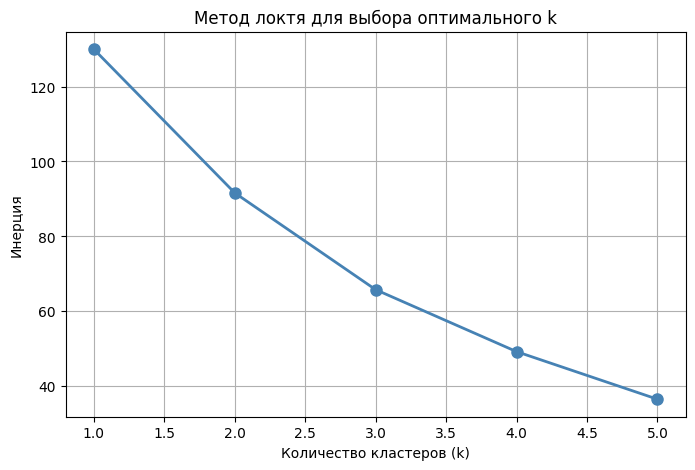

 Рекомендуемое число кластеров: 2


In [6]:
# БЛОК 6: Определение оптимального числа кластеров (метод локтя)

pivot = df_merged.pivot_table(index='object_id', columns='group_name', values='value_fact', aggfunc='sum', fill_value=0)
forbidden = ['cluster', 'cluster_type_based', 'share_own', 'share_sub', 'share_overhead']
pivot = pivot.drop(columns=[c for c in forbidden if c in pivot.columns], errors='ignore')
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
pivot_norm = pivot_norm.loc[pivot_norm.sum(axis=1) > 0]
print(f"Матрица долей затрат: {pivot_norm.shape[0]} объектов, {pivot_norm.shape[1]} групп")

scaler = StandardScaler()
X = scaler.fit_transform(pivot_norm)

inertia = []
k_range = range(1, min(6, len(X)))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция')
plt.title('Метод локтя для выбора оптимального k')
plt.grid(True)
plt.show()

if len(inertia) >= 3:
    diffs = [inertia[i] - inertia[i+1] for i in range(len(inertia)-1)]
    if diffs:
        elbow = diffs.index(max(diffs)) + 2
        print(f" Рекомендуемое число кластеров: {elbow}")
    else:
        print(" Недостаточно данных")

In [7]:
# БЛОК 7: KMeans кластеризация по структуре затрат и t-SNE визуализация

pivot = df_merged.pivot_table(index='object_id', columns='group_name', values='value_fact', aggfunc='sum', fill_value=0)
pivot = pivot.drop(columns=[c for c in forbidden if c in pivot.columns], errors='ignore')
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
pivot_norm = pivot_norm.loc[pivot_norm.sum(axis=1) > 0]
print(f"Матрица долей затрат: {pivot_norm.shape[0]} объектов, {pivot_norm.shape[1]} групп")

scaler = StandardScaler()
X = scaler.fit_transform(pivot_norm)

inertia = []
k_range = range(1, min(6, len(X)))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)
if len(inertia) >= 3:
    diffs = [inertia[i] - inertia[i+1] for i in range(len(inertia)-1)]
    k_opt = diffs.index(max(diffs)) + 2 if max(diffs) > 0 else 3
else:
    k_opt = 3
print(f"Оптимальное число кластеров: {k_opt}")

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
clusters = pd.Series(clusters).astype(int)
print("Уникальные кластеры:", clusters.unique())
print("Распределение объектов:")
pivot_norm['cluster'] = clusters.values
print("Средние доли затрат по кластерам:")
display(pivot_norm.groupby('cluster').mean().round(3))
perplex = 7
tsne = TSNE(n_components=2, random_state=42, perplexity=perplex)
X_tsne = tsne.fit_transform(X)
df_tsne = pd.DataFrame(X_tsne, columns=['t1', 't2'])
df_tsne['cluster'] = clusters
df_tsne['object'] = pivot_norm.index
fig = px.scatter(df_tsne, x='t1', y='t2', color='cluster', text='object',
                 title=f't-SNE визуализация кластеров (KMeans, k={k_opt})',
                 labels={'t1': 't-SNE компонента 1', 't2': 't-SNE компонента 2'})
fig.update_traces(textposition='top center', textfont_size=9)
fig.show()

print("Интерпретация кластеров")
for cluster in sorted(pivot_norm['cluster'].unique()):
    count = (pivot_norm['cluster'] == cluster).sum()
    profile = pivot_norm[pivot_norm['cluster'] == cluster].mean()
    top3 = profile.nlargest(3)
    objects = ', '.join(pivot_norm[pivot_norm['cluster'] == cluster].index.tolist())
    print(f"Кластер {cluster} ({count} объекта)" if count == 1 else f"\n КЛАСТЕР {cluster} ({count} объектов)")
    print(" Основные статьи затрат (топ-3):")
    for group, val in top3.items():
        print(f" - {group}: {val:.1%}")
    print(f" Объекты: {objects}")

print(f" Оптимальное число кластеров k = {k_opt}.")

Матрица долей затрат: 13 объектов, 10 групп
Оптимальное число кластеров: 2
Уникальные кластеры: [0 1]
Распределение объектов:
Средние доли затрат по кластерам:


group_name,гарантия,итр,материалы,офисные затраты,премиальный фонд,проектирование,строительные часы,субподряд,техника,услуги
cluster,,,,,,,,,,
0,0.004,0.049,0.308,0.103,0.001,0.01,0.122,0.299,0.064,0.040
1,0.000,0.035,0.006,0.000,0.005,0.00,0.063,0.417,0.345,0.128


Интерпретация кластеров

 КЛАСТЕР 0 (12 объектов)
 Основные статьи затрат (топ-3):
 - материалы: 30.8%
 - субподряд: 29.9%
 - строительные часы: 12.2%
 Объекты: 210607, 210616_1, 210616_2, 210616_3, 230523, 230623, 231003, 231213, 240612, 240704, 240904, 250310
Кластер 1 (1 объекта)
 Основные статьи затрат (топ-3):
 - cluster: 100.0%
 - субподряд: 41.7%
 - техника: 34.5%
 Объекты: 210616
 Оптимальное число кластеров k = 2.


% работ по объектам (собственные / субподряд / прочее):


,other_pct,own_pct,subcontractor_pct
0,5.7,48.8,45.6
1,0.5,57.8,41.8
2,5.7,75.5,18.8
3,18.4,80.5,1.1
4,14.8,64.4,20.7
5,12.4,68.1,19.5
6,14.1,53.4,32.5
7,10.8,59.8,29.3
8,11.5,21.6,66.9
9,8.5,35.7,55.8


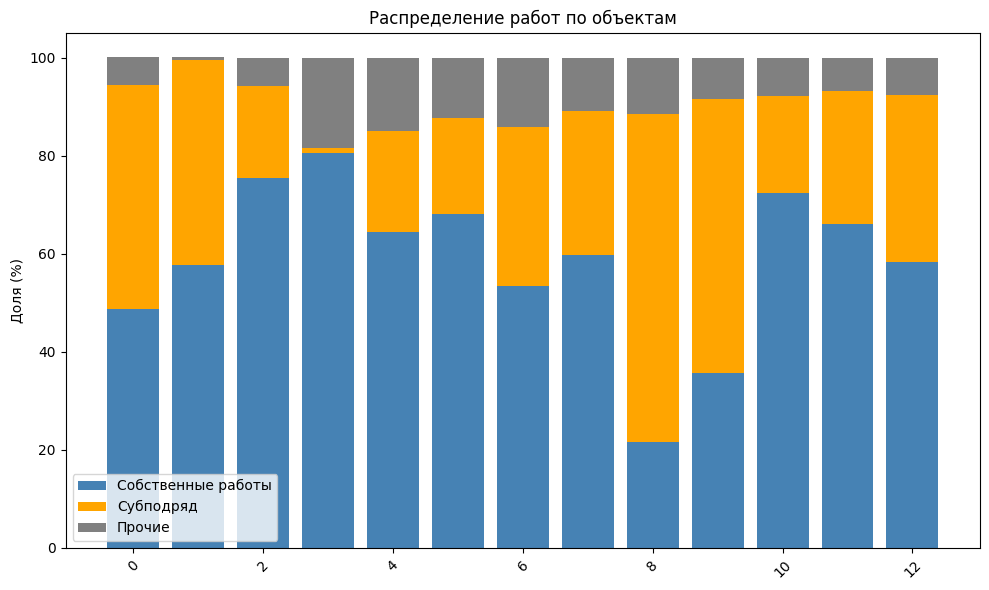

Детализация по объектам:
   0: собственные 48.8%, субподряд 45.6%
   1: собственные 57.8%, субподряд 41.8%
   2: собственные 75.5%, субподряд 18.8%
   3: собственные 80.5%, субподряд 1.1%
   4: собственные 64.4%, субподряд 20.7%
   5: собственные 68.1%, субподряд 19.5%
   6: собственные 53.4%, субподряд 32.5%
   7: собственные 59.8%, субподряд 29.3%
   8: собственные 21.6%, субподряд 66.9%
   9: собственные 35.7%, субподряд 55.8%
   10: собственные 72.4%, субподряд 19.8%
   11: собственные 66.0%, субподряд 27.2%
   12: собственные 58.4%, субподряд 34.0%


In [8]:
# БЛОК 7.1: Анализ распределения работ (собственные / субподряд / прочие)

own = ['строительные часы', 'техника', 'материалы', 'итр', 'услуги', 'гарантия']
sub = ['субподряд', 'проектирование']
other = ['офисные затраты', 'прочие']

def simplify_cost_type(ct):
    if ct in own:
        return 'own'
    elif ct in sub:
        return 'subcontractor'
    else:
        return 'other'

df_merged['cost_type_simple'] = df_merged['group_name'].apply(simplify_cost_type)
df_merged['value_fact'] = pd.to_numeric(df_merged['value_fact'], errors='coerce').fillna(0)

cost_by_type = df_merged.groupby(['object_id', 'cost_type_simple'])['value_fact'].sum().reset_index()
total_by_object = cost_by_type.groupby('object_id')['value_fact'].sum().reset_index()
total_by_object.columns = ['object_id', 'total_cost']


pivot_type = cost_by_type.pivot(index='object_id', columns='cost_type_simple', values='value_fact').fillna(0)
pivot_type = pivot_type.merge(total_by_object, on='object_id')
for col in ['own', 'subcontractor', 'other']:
    if col in pivot_type.columns:
        pivot_type[f'{col}_pct'] = pivot_type[col] / pivot_type['total_cost'] * 100
        pivot_type[f'{col}_pct'] = pivot_type[f'{col}_pct'].round(1)


pct_cols = [c for c in pivot_type.columns if c.endswith('_pct')]
pct_cols.sort()
print("% работ по объектам (собственные / субподряд / прочее):")
display(pivot_type[pct_cols])
pivot_type['object_id'] = pivot_type.index


objects = pivot_type['object_id'].tolist()
own_vals = pivot_type['own_pct'].tolist() if 'own_pct' in pivot_type else [0]*len(objects)
sub_vals = pivot_type['subcontractor_pct'].tolist() if 'subcontractor_pct' in pivot_type else [0]*len(objects)
other_vals = pivot_type['other_pct'].tolist() if 'other_pct' in pivot_type else [0]*len(objects)


fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(objects, own_vals, label='Собственные работы', color='steelblue')
ax.bar(objects, sub_vals, bottom=own_vals, label='Субподряд', color='orange')
ax.bar(objects, other_vals, bottom=[own_vals[i]+sub_vals[i] for i in range(len(objects))], label='Прочие', color='gray')
ax.set_ylabel('Доля (%)')
ax.set_title('Распределение работ по объектам')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Детализация по объектам:")
for i, obj in enumerate(objects):
    o = own_vals[i]
    s = sub_vals[i]
    print(f"   {obj}: собственные {o:.1f}%, субподряд {s:.1f}%")

In [9]:
#Блок 8: KMeans кластеризация по категориям (собственные / субподряд / прочее)

def simplify_cost_type(cost_type):
    if cost_type == 'own':
        return 'own'
    elif cost_type == 'subcontractor':
        return 'subcontractor'
    else:
        return 'other'

df_merged['cost_type_simple'] = df_merged['cost_type'].apply(simplify_cost_type)
cost_simple = df_merged.groupby(['object_id', 'cost_type_simple'])['value_fact'].sum().reset_index()
pivot_simple = cost_simple.pivot(index='object_id', columns='cost_type_simple', values='value_fact').fillna(0)
pivot_simple['total'] = pivot_simple.sum(axis=1)
for col in ['own', 'subcontractor', 'other']:
    pivot_simple[f'share_{col}'] = pivot_simple[col] / pivot_simple['total']

features_clust = ['share_own', 'share_subcontractor', 'share_other']
X_clust = pivot_simple[features_clust].values
scaler_simple = StandardScaler()
X_scaled_simple = scaler_simple.fit_transform(X_clust)

k_opt_simple = 2
kmeans_simple = KMeans(n_clusters=k_opt_simple, random_state=42, n_init=10)
pivot_simple['cluster_simple'] = kmeans_simple.fit_predict(X_scaled_simple).astype(int)
print(f"Распределение по кластерам (k={k_opt_simple}):")
print(pivot_simple['cluster_simple'].value_counts().sort_index())

perplex = 7
tsne_simple = TSNE(n_components=2, random_state=42, perplexity=perplex)
X_tsne_simple = tsne_simple.fit_transform(X_scaled_simple)
objects_list = pivot_simple.index.tolist()

df_tsne_simple = pd.DataFrame({
    't1': X_tsne_simple[:, 0],
    't2': X_tsne_simple[:, 1],
    'cluster': pivot_simple['cluster_simple'].astype(str),
    'object': objects_list
})

fig = px.scatter(
    df_tsne_simple, x='t1', y='t2',
    color='cluster',
    color_discrete_map={'0': 'blue', '1': 'red', '2': 'green'},
    text='object',
    title=f't-SNE визуализация кластеров (категории: собственные/субподряд/прочее, k={k_opt_simple})',
    labels={'t1': 't-SNE компонента 1', 't2': 't-SNE компонента 2'}
)
fig.update_traces(textposition='top center', textfont_size=12, marker=dict(size=12))
fig.show()

print("Интерпретация кластеров (по категориям)И")
for cluster in sorted(pivot_simple['cluster_simple'].unique()):
    cnt = (pivot_simple['cluster_simple'] == cluster).sum()
    mask = pivot_simple['cluster_simple'] == cluster
    own_avg = pivot_simple.loc[mask, 'share_own'].mean()
    sub_avg = pivot_simple.loc[mask, 'share_subcontractor'].mean()
    other_avg = pivot_simple.loc[mask, 'share_other'].mean()
    objects = ', '.join(pivot_simple[mask].index.tolist())
    print(f"Кластер {cluster} ({cnt} объектов)")
    print(f" • Собственные работы: {own_avg:.1%}")
    print(f" • Субподряд: {sub_avg:.1%}")
    print(f" • Прочее (офисные, прочие): {other_avg:.1%}")
    print(f" • Объекты: {objects}")

if k_opt_simple == 2:
    print(" Кластеризация по категориям выделила два основных типа объектов:")
    print(" • Кластер 0 – объекты с высокой долей собственных работ ( >70%)")
    print(" • Кластер 1 – объекты со значительной долей субподряда и прочих затрат")


Распределение по кластерам (k=2):
cluster_simple
0    9
1    4
Name: count, dtype: int64


Интерпретация кластеров (по категориям)И
Кластер 0 (9 объектов)
 • Собственные работы: 66.5%
 • Субподряд: 22.6%
 • Прочее (офисные, прочие): 10.9%
 • Объекты: 210616_1, 210616_2, 210616_3, 230523, 230623, 231003, 240704, 240904, 250310
Кластер 1 (4 объектов)
 • Собственные работы: 41.0%
 • Субподряд: 52.5%
 • Прочее (офисные, прочие): 6.5%
 • Объекты: 210607, 210616, 231213, 240612
 Кластеризация по категориям выделила два основных типа объектов:
 • Кластер 0 – объекты с высокой долей собственных работ ( >70%)
 • Кластер 1 – объекты со значительной долей субподряда и прочих затрат


In [10]:
cluster_df = pivot_simple[['cluster_simple']].reset_index()
cluster_df.columns = ['object_id', 'cluster']
cluster_df.to_sql('cluster_assignments', engine, if_exists='replace', index=False)

df_merged_clusters = df_merged.merge(pivot_simple[['cluster_simple']].reset_index(), on='object_id', how='left')
cost_stats = df_merged_clusters.groupby(['cluster_simple', 'expense_id', 'group_name'])['value_fact'].sum().reset_index()
cost_stats = cost_stats[cost_stats['value_fact'] > 0]
total_by_cluster = cost_stats.groupby('cluster_simple')['value_fact'].sum().reset_index()
total_by_cluster.columns = ['cluster_simple', 'total_cluster_cost']
cost_stats = cost_stats.merge(total_by_cluster, on='cluster_simple')
cost_stats['pct_of_cluster'] = (cost_stats['value_fact'] / cost_stats['total_cluster_cost']) * 100
cost_stats.to_sql('cluster_cost_stats', engine, if_exists='replace', index=False)
print(cost_stats[['cluster_simple', 'expense_id', 'group_name', 'pct_of_cluster']].head())

   cluster_simple expense_id group_name  pct_of_cluster
0               0      01.01  материалы        0.000124
1               0      01.02  материалы        0.000231
2               0      01.03  материалы        0.003774
3               0      01.04  материалы        0.058535
4               0      01.05  материалы       22.192337


In [11]:
#Блок 9: Сравнение моделей (отбор признаков + подбор гиперпараметров)

df_model = dim_objects[['object_id', 'contract_price_plan', 'profit_plan']].copy()
if 'volume_sqm' in dim_objects_sqm.columns:
    sqm = dim_objects_sqm[['object_id', 'volume_sqm']]
    df_model = df_model.merge(sqm, on='object_id', how='left')
    df_model['volume_sqm'] = df_model['volume_sqm'].fillna(df_model['volume_sqm'].median())
else:
    df_model['volume_sqm'] = 1
if 'number_hours' in dim_objects_sqm.columns:
    hours = dim_objects_sqm[['object_id', 'number_hours']]
    df_model = df_model.merge(hours, on='object_id', how='left')
    df_model['number_hours'] = df_model['number_hours'].fillna(0)
else:
    df_model['number_hours'] = 0

for group in pivot_norm.columns:
    if group not in ['cluster', 'cluster_type_based', 'cluster_work']:
        df_model[f'share_{group}'] = df_model['object_id'].map(pivot_norm[group]).fillna(0)

df_model['target'] = df_model['object_id'].map(pivot_simple['cluster_simple']).fillna(0).astype(int)
exclude_cols = ['object_id', 'target']
feature_cols = [c for c in df_model.columns if c not in exclude_cols]
X = df_model[feature_cols].copy()
y = df_model['target']
print(f"Размер выборки: {X.shape[0]} объектов, {X.shape[1]} признаков (до отбора)")
print("Распределение целевых классов:", y.value_counts().to_dict())

selector = SelectKBest(f_classif, k=min(5, X.shape[1]))
X_selected = selector.fit_transform(X, y)
selected_features = [feature_cols[i] for i in selector.get_support(indices=True)]
print(f"Кол-во признаков: {len(selected_features)}")
print("Признаки:", selected_features)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM (RBF)': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}
param_grids = {
    'Logistic Regression': {'C': [0.1, 1.0, 10.0], 'penalty': ['l2']},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [3, 5]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'max_depth': [2, 3]},
    'SVM (RBF)': {'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 'auto']},
    'KNN': {'n_neighbors': [2, 3, 4], 'weights': ['uniform', 'distance']}
}
loo = LeaveOneOut()
results = []
best_model = None
best_f1 = 0

for name, model in models.items():
    print(f"{name}")
    try:
        grid = GridSearchCV(model, param_grids[name], cv=loo, scoring='f1_weighted', error_score=0)
        grid.fit(X_selected, y)
        best_estimator = grid.best_estimator_
        y_pred_all = []
        for train_idx, test_idx in loo.split(X_selected):
            X_tr, X_te = X_selected[train_idx], X_selected[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
            if len(np.unique(y_tr)) == 1:
                y_pred_all.append(np.unique(y_tr)[0])
            else:
                clf = best_estimator.__class__(**best_estimator.get_params())
                clf.fit(X_tr, y_tr)
                y_pred_all.append(clf.predict(X_te)[0])
        acc = accuracy_score(y, y_pred_all)
        prec = precision_score(y, y_pred_all, average='weighted', zero_division=0)
        rec = recall_score(y, y_pred_all, average='weighted', zero_division=0)
        f1 = f1_score(y, y_pred_all, average='weighted', zero_division=0)
        results.append({'Модель': name, 'Лучшие параметры': str(grid.best_params_),
                        'Accuracy': f"{acc:.2%}", 'Precision': f"{prec:.2%}",
                        'Recall': f"{rec:.2%}", 'F1-score': f"{f1:.2%}"})
        print(f" Accuracy: {acc:.2%}, F1: {f1:.2%}, Параметры: {grid.best_params_}")
        if f1 > best_f1:
            best_f1 = f1
            best_model = best_estimator
            best_model_name = name
    except Exception as e:
        print(f" Ошибка: {e}")
        results.append({'Модель': name, 'Лучшие параметры': 'ошибка', 'Accuracy': 'ошибка',
                        'Precision': 'ошибка', 'Recall': 'ошибка', 'F1-score': 'ошибка'})

print("Сводная таблица:")
results_df = pd.DataFrame(results)
display(results_df)
print(f"Лучшая модель: {best_model_name} (F1 = {best_f1:.2%})")

if best_model is not None:
    best_model.fit(X_selected, y)
    joblib.dump(best_model, 'best_cluster_model.pkl')
    joblib.dump(selector, 'feature_selector.pkl')
    print("Лучшая модель и селектор признаков сохранены.")
else:
    print("Не удалось обучить ни одну модель.")

Размер выборки: 13 объектов, 14 признаков (до отбора)
Распределение целевых классов: {0: 9, 1: 4}
Кол-во признаков: 5
Признаки: ['number_hours', 'share_материалы', 'share_офисные затраты', 'share_строительные часы', 'share_субподряд']
Logistic Regression
 Accuracy: 84.62%, F1: 82.82%, Параметры: {'C': 10.0, 'penalty': 'l2'}
Random Forest
 Accuracy: 92.31%, F1: 91.96%, Параметры: {'max_depth': 3, 'n_estimators': 50}
Gradient Boosting
 Accuracy: 100.00%, F1: 100.00%, Параметры: {'max_depth': 2, 'n_estimators': 100}
SVM (RBF)
 Accuracy: 69.23%, F1: 56.64%, Параметры: {'C': 0.1, 'gamma': 'scale'}
KNN
 Accuracy: 69.23%, F1: 56.64%, Параметры: {'n_neighbors': 4, 'weights': 'uniform'}
Сводная таблица:


,Модель,Лучшие параметры,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,"{'C': 10.0, 'penalty': 'l2'}",84.62%,87.41%,84.62%,82.82%
1,Random Forest,"{'max_depth': 3, 'n_estimators': 50}",92.31%,93.08%,92.31%,91.96%
2,Gradient Boosting,"{'max_depth': 2, 'n_estimators': 100}",100.00%,100.00%,100.00%,100.00%
3,SVM (RBF),"{'C': 0.1, 'gamma': 'scale'}",69.23%,47.93%,69.23%,56.64%
4,KNN,"{'n_neighbors': 4, 'weights': 'uniform'}",69.23%,47.93%,69.23%,56.64%


Лучшая модель: Gradient Boosting (F1 = 100.00%)
Лучшая модель и селектор признаков сохранены.


In [12]:
#Блок 10 Обучение модели на 5 отобранных признаках (для бота)
X_final = X_selected
y_final = y
new_model = GradientBoostingClassifier(max_depth=2, n_estimators=50, random_state=42)
new_model.fit(X_final, y_final)
joblib.dump(new_model, 'gradient_boosting_model_5feat.pkl')

['gradient_boosting_model_5feat.pkl']

In [13]:
#Блок 10.1: Подготовка данных для градиентного бустинга

y = df_model['target'].values
X = df_model[feature_cols].values
print(f"Размер выборки: {X.shape[0]} объектов")
print(f"Число признаков: {X.shape[1]}")
print(f"Распределение целевых классов: {np.bincount(y)}")
print(" (0 – объекты с преобладанием собственных работ, 1 – с преобладанием супбодряда)")

scaler_gb = StandardScaler()
X_scaled = scaler_gb.fit_transform(X)

Размер выборки: 13 объектов
Число признаков: 14
Распределение целевых классов: [9 4]
 (0 – объекты с преобладанием собственных работ, 1 – с преобладанием супбодряда)


In [14]:
#Блок 10.2: Подбор гиперпараметров (GridSearchCV + K-Fold)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
param_grid = {'n_estimators': [30, 50, 70], 'max_depth': [2, 3],
              'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}
gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(gb, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_scaled, y)
print("Лучшие гиперпараметры:")
for param, value in grid_search.best_params_.items():
    print(f" {param}: {value}")
print(f"Лучшее F1 на кросс-валидации: {grid_search.best_score_:.2%}")
best_gb = grid_search.best_estimator_

Лучшие гиперпараметры:
 learning_rate: 0.05
 max_depth: 2
 n_estimators: 30
 subsample: 0.8
Лучшее F1 на кросс-валидации: 88.89%


In [15]:
#Блок 11 Предсказание для тестового объекта

test_object_id = df_model['object_id'].iloc[-1]  # '230523'
print(f"Тестовый объект: {test_object_id}")
X_test = df_model[df_model['object_id'] == test_object_id][feature_cols].values
X_test_scaled = scaler_gb.transform(X_test)
pred_cluster = best_gb.predict(X_test_scaled)[0]
pred_proba = best_gb.predict_proba(X_test_scaled)[0]
print(f"Предсказанный кластер: {pred_cluster}")
print(f"Вероятности: {dict(zip(best_gb.classes_, pred_proba))}")
actual_cluster = df_model[df_model['object_id'] == test_object_id]['target'].values[0]
print(f"Фактический кластер: {actual_cluster}")
if pred_cluster == actual_cluster:
    print("Верно")
else:
    print("Ошибка")

Тестовый объект: 250310
Предсказанный кластер: 0
Вероятности: {np.int64(0): np.float64(0.9318469828364063), np.int64(1): np.float64(0.06815301716359369)}
Фактический кластер: 0
Верно


In [16]:
#Блок 12 рекомендации для предсказанного кластера

objects_in_cluster = pivot_simple[pivot_simple['cluster_simple'] == pred_cluster].index.tolist()
print(f"Объекты кластера {pred_cluster}: {objects_in_cluster}")

df_cluster = df_merged[df_merged['object_id'].isin(objects_in_cluster)]
group_summary = df_cluster.groupby('group_name')['value_fact'].sum().sort_values(ascending=False)
total_cluster_cost = group_summary.sum()
group_shares = (group_summary / total_cluster_cost) * 100

print("Группы с наибольшими расходами:")
for group, share in group_shares.head(3).items():
    print(f"  - {group}: {share:.1f}%")
print("Группы с наименьшими расходами")
for group, share in group_shares.tail(3).items():
    print(f"  - {group}: {share:.1f}%")

code_summary = df_cluster.groupby(['expense_id', 'group_name'])['value_fact'].sum().reset_index()
code_summary = code_summary.sort_values('value_fact', ascending=False)
code_summary['pct_of_cluster'] = (code_summary['value_fact'] / total_cluster_cost) * 100
group_totals = code_summary.groupby('group_name')['value_fact'].sum()
code_summary['pct_of_group'] = code_summary.apply(lambda row: (row['value_fact'] / group_totals[row['group_name']]) * 100, axis=1)

positive_codes = code_summary[code_summary['value_fact'] > 0]
positive_codes_filtered = positive_codes[positive_codes['pct_of_cluster'] > 0.01]
positive_codes_sorted = positive_codes_filtered.sort_values('pct_of_cluster', ascending=True)
smallest_codes = positive_codes_sorted.head(5)

print("Топ-5 кодов по затратам (наибольшие расходы):")
for _, row in positive_codes.head(5).iterrows():
    print(f"  - Код {row['expense_id']} ({row['group_name']}): {row['pct_of_cluster']:.2f}% от общих затрат кластера, {row['pct_of_group']:.2f}% от группы '{row['group_name']}'")
print("Топ-5 кодов по затратам (наименьшие расходы)::")
if not smallest_codes.empty:
    for _, row in smallest_codes.iterrows():
        print(f"  - Код {row['expense_id']} ({row['group_name']}): {row['pct_of_cluster']:.4f}% от общих затрат кластера, {row['pct_of_group']:.2f}% от группы '{row['group_name']}'")
else:
    print("  Нет кодов с долей более 0.01%.")

if pred_cluster == 0:
    print("РЕКОМЕНДАЦИЯ: Кластер 0 – объекты с преобладанием собственных работ.")
    print("   Оптимизировать использование строительных часов, техники и материалов.")
    print("   Усилить контроль над ИТР и сокращать офисные затраты.")
else:
    print("РЕКОМЕНДАЦИЯ: Кластер 1 – объекты со значительной долей субподряда.")
    print("   Пересмотреть договоры с субподрядчиками, особенно по кодам с наибольшими расходами.")
    print("   Контролировать стоимость материалов и строительных часов и т.д, переданных на субподряд.")

Объекты кластера 0: ['210616_1', '210616_2', '210616_3', '230523', '230623', '231003', '240704', '240904', '250310']
Группы с наибольшими расходами:
  - материалы: 43.5%
  - субподряд: 21.9%
  - строительные часы: 10.4%
Группы с наименьшими расходами
  - проектирование: 0.8%
  - гарантия: 0.5%
  - премиальный фонд: 0.2%
Топ-5 кодов по затратам (наибольшие расходы):
  - Код 01.05 (материалы): 22.19% от общих затрат кластера, 50.99% от группы 'материалы'
  - Код 13.01 (строительные часы): 8.74% от общих затрат кластера, 84.21% от группы 'строительные часы'
  - Код 03.047 (офисные затраты): 5.71% от общих затрат кластера, 71.45% от группы 'офисные затраты'
  - Код 14.63 (субподряд): 5.60% от общих затрат кластера, 25.57% от группы 'субподряд'
  - Код 06.36 (материалы): 4.53% от общих затрат кластера, 10.41% от группы 'материалы'
Топ-5 кодов по затратам (наименьшие расходы)::
  - Код 15.09 (техника): 0.0117% от общих затрат кластера, 0.16% от группы 'техника'
  - Код 16.24-09 (услуги): 0.0

In [17]:
#Блок 13: Leave-One-Out тестирование каждого объекта
loo = LeaveOneOut()
y_true = []
y_pred = []
results_loo = []
for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = GradientBoostingClassifier(**grid_search.best_params_, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]
    true = y_test[0]
    y_true.append(true)
    y_pred.append(pred)
    obj_id = df_model.iloc[test_idx[0]]['object_id']
    results_loo.append({'object_id': obj_id, 'true_cluster': true, 'pred_cluster': pred, 'correct': true == pred})

accuracy = accuracy_score(y_true, y_pred)
print(f"Общая точность LOO-кросс-валидации: {accuracy:.2%}")
results_loo_df = pd.DataFrame(results_loo)
print("Результаты по каждому объекту:")
print(results_loo_df.to_string(index=False))

errors = results_loo_df[~results_loo_df['correct']]
if len(errors) > 0:
    print(f"Ошибка классификаци ({len(errors)}):")
    for _, row in errors.iterrows():
        print(f"Объект {row['object_id']}: факт {row['true_cluster']} - предсказано {row['pred_cluster']}")
else:
    print("Все объекты классифицированы верно!")

Общая точность LOO-кросс-валидации: 92.31%
Результаты по каждому объекту:
object_id  true_cluster  pred_cluster  correct
   210616             1             0    False
 210616_1             0             0     True
 210616_2             0             0     True
 210616_3             0             0     True
   231003             0             0     True
   240904             0             0     True
   230623             0             0     True
   231213             1             1     True
   210607             1             1     True
   230523             0             0     True
   240612             1             1     True
   240704             0             0     True
   250310             0             0     True
Ошибка классификаци (1):
Объект 210616: факт 1 - предсказано 0


In [18]:
#Блок 13 Сохранение модели, селектора признаков и scaler
joblib.dump(best_gb, 'gradient_boosting_model.pkl')
joblib.dump(scaler_gb, 'scaler_gb.pkl')
joblib.dump(selector, 'feature_selector.pkl')
with open('feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

In [19]:
df_model.to_sql('model_features', engine, if_exists='replace', index=False)

13

In [20]:
#Блок 14: Обучение упрощённой модели на 4 признаках (дя бота)
feature_cols_4 = ['материалы', 'офисные затраты', 'строительные часы', 'субподряд']

df_model_4 = dim_objects[['object_id']].copy()
for col in feature_cols_4:
    df_model_4[col] = df_model_4['object_id'].map(pivot_norm[col]).fillna(0)

df_model_4['target'] = df_model_4['object_id'].map(pivot_simple['cluster_simple']).fillna(0).astype(int)
df_model_4 = df_model_4.dropna()

print("Размер выборки:", df_model_4.shape)
print("Признаки:", feature_cols_4)
print("Распределение целевых классов:", df_model_4['target'].value_counts())

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, f1_score

X = df_model_4[feature_cols_4]
y = df_model_4['target']

loo = LeaveOneOut()
y_true, y_pred = [], []
for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model = GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42)
    model.fit(X_train, y_train)
    y_pred.append(model.predict(X_test)[0])
    y_true.append(y_test)

print(f"LOO Accuracy: {accuracy_score(y_true, y_pred):.2%}")
print(f"LOO F1 (weightd): {f1_score(y_true, y_pred, average='weighted'):.2%}")

final_model = GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42)
final_model.fit(X, y)

import joblib
joblib.dump(final_model, 'gradient_boosting_model.pkl')
joblib.dump(None, 'feature_selector.pkl')

Размер выборки: (13, 6)
Признаки: ['материалы', 'офисные затраты', 'строительные часы', 'субподряд']
Распределение целевых классов: target
0    9
1    4
Name: count, dtype: int64
LOO Accuracy: 92.31%
LOO F1 (weightd): 92.51%


['feature_selector.pkl']

In [21]:
#Проверка таблиц
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", engine)
print("Таблицы в БД:")
print(tables)
objects = pd.read_sql_query("SELECT object_id FROM dim_objects", engine)
print("Объекты в dim_objects:")
print(objects['object_id'].tolist())

Таблицы в БД:
                  name
0         dim_expenses
1          dim_objects
2    fact_transactions
3      dim_objects_sqm
4  cluster_assignments
5   cluster_cost_stats
6       model_features
Объекты в dim_objects:
['210616', '210616_1', '210616_2', '210616_3', '231003', '240904', '230623', '231213', '210607', '230523', '240612', '240704', '250310']


In [22]:
from google.colab import files
files.download('stroy_analytics.db')
files.download('gradient_boosting_model.pkl')
files.download('feature_selector.pkl')
files.download('scaler_gb.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>